# Random Forest and Adababoost classifier from scratch in pure Python.

This notebook implements a Random Forest and adaboost classifiers from scratch in pure Python. We will use the `PhiUSIIL_Phishing_URL_Dataset` to detect phishing URLs.

### Objectives:
1.  **Pure Python Implementation**: Build a Random Forest with minimal external dependencies (standard library + a bit of math).
2.  **Comparative Analysis**: Compare our scratch implementations with `scikit-learn`.
3.  **Hyperparameter Variation**: Plot how parameters like tree count and depth affect performance on the original dataset. *WIP* - I mean to implement cross parameter scoring.
4.  **Robustness Evaluation**: We dirty the training data with assymetric noise, and re-test the models to see how our model performs with less optimal data, allowing us to evaluate accuracy, precision, recall and F1. (*WIP* I'm not sure I'm modulating the hyper parameters for the sk learn model)

---


Boilerplate: Data Preprocessing

We'll load the `PhiUSIIL_Phishing_URL_Dataset.csv` and select numerical features. For simplicity in this demo, we'll focus on the most relevant numerical columns.


In [3]:
import math # Import math for logarithmic operations in entropy
import random # Import random for bootstrap sampling and feature selection
import csv # Import csv for reading the dataset file
import matplotlib.pyplot as plt # Import pyplot for visualizing results
from sklearn.ensemble import RandomForestClassifier # Import sklearn version for benchmarking
from sklearn.model_selection import train_test_split # Import utility for train/test partitioning
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score # Import metrics for model evaluation

# Set seed for reproducibility
random.seed(42) # Fix seed to ensure consistent results across runs

# Sanity Check: Ensure imports work
print("Imports successful!") # Confirm that all modules are loaded correctly


Imports successful!


## 0.1: Data Preprocessing

We'll load the `PhiUSIIL_Phishing_URL_Dataset.csv` and select numerical features. For simplicity in this demo, we'll focus on the most relevant numerical columns.


In [4]:
class Row: # Define a class to represent a single data point
    def __init__(self, features, label): # Constructor for the Row class
        self.features = features # Assign features list to the object
        self.label = label # Assign target label to the object

def load_phishing_data(filepath, limit=2000): # Function to load dataset from CSV
    data = [] # Initialize list to store data rows
    with open(filepath, 'r', encoding='utf-8') as f: # Open file with UTF-8 encoding
        reader = csv.DictReader(f) # Create a dictionary reader for the CSV
        # We'll pick a subset of columns that are numerical
        feature_cols = [ # Define names of numerical feature columns
            'URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 
            'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 
            'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
            'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
            'IsHTTPS', 'LineOfCode', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive'
        ]
        
        count = 0 # Initialize counter for limiting data load
        for r in reader: # Loop through each row in the CSV file
            try: # Use try-except to catch parsing errors
                features = [float(r[col]) for col in feature_cols] # Convert features to floating point numbers
                label = int(r['label']) # Convert label to an integer
                data.append(Row(features, label)) # Store data as a Row instance
                count += 1 # Increment the row counter
                if count >= limit: # Check if the specified limit is reached
                    break # Stop loading rows if limit reached
            except (ValueError, KeyError): # Handle missing columns or conversion errors
                continue # Skip the current row and move to the next one
    return data, feature_cols # Return the list of Row objects and feature names

dataset, feature_names = load_phishing_data('PhiUSIIL_Phishing_URL_Dataset.csv', limit=5000) # Load 5000 records from the dataset

# Split into train/test
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42) # Split data into 80% training and 20% testing

# Sanity Check: Print counts
print(f"Loaded {len(dataset)} rows with {len(feature_names)} features.") # Display total loaded rows and feature count
print(f"Train size: {len(train_data)}, Test size: {len(test_data)}") # Display sizes of the training and testing sets


Loaded 5000 rows with 21 features.
Train size: 4000, Test size: 1000


## 0.2: Hardcoded Helper Functions

These functions handle impurity calculations and threshold finding.


In [5]:
# H = - \sum_{i} p_i \log_2(p_i)


def count_labels(data_subset): # Helper to count positive and negative labels in a subset
    pos = 0 # Initialize positive label count
    neg = 0 # Initialize negative label count
    for row in data_subset: # Iterate through each row in the subset
        if row.label == 1: # Check if the label is positive (1)
            pos += 1 # Increment positive counter
        else: # Label is negative (0)
            neg += 1 # Increment negative counter
    return pos, neg # Return the counts of positive and negative labels

def entropy(data_subset): # Calculate Shannon entropy for a subset of data
    if not data_subset: return 0 # Return 0 entropy if the subset is empty
    pos, neg = count_labels(data_subset) # Get label counts for the subset
    total = pos + neg # Calculate total number of samples in the subset
    ent = 0 # Initialize entropy value to 0
    for count in [pos, neg]: # Iterate over both class counts
        if count > 0: # Ensure count is positive to avoid log(0)
            p = count / total # Calculate probability of the class
            ent -= p * math.log2(p) # Subtract p*log2(p) from entropy
    return ent # Return the final entropy value

def gini(data_subset): # Calculate Gini impurity for a subset of data
    if not data_subset: return 0 # Return 0 impurity if the subset is empty
    pos, neg = count_labels(data_subset) # Get label counts for the subset
    total = pos + neg # Calculate total number of samples in the subset
    imp = 1 # Initialize Gini impurity starting at 1
    for count in [pos, neg]: # Iterate over both class counts
        p = count / total # Calculate probability of the class
        imp -= p**2 # Subtract squared probability from impurity
    return imp # Return the final Gini impurity value

def split_data(data_subset, feature_index, threshold): # Partition data into two subsets based on a threshold
    left_data = [] # List for rows where feature value is <= threshold
    right_data = [] # List for rows where feature value is > threshold
    for row in data_subset: # Iterate through each row in the subset
        if row.features[feature_index] <= threshold: # Check split condition
            left_data.append(row) # Add to left subset if condition is met
        else: # Condition not met
            right_data.append(row) # Add to right subset
    return left_data, right_data # Return both subsets

def calc_split_score(left_data, right_data, criterion): # Calculate weighted impurity score for a split
    total = len(left_data) + len(right_data) # Calculate total samples across both subsets
    if total == 0: return 0 # Return 0 if no samples exist to avoid division by zero
    left_weight = len(left_data) / total # Calculate weight of the left subset
    right_weight = len(right_data) / total # Calculate weight of the right subset
    
    if criterion == "entropy": # Use entropy if specified as the criterion
        return left_weight * entropy(left_data) + right_weight * entropy(right_data) # Weighted entropy sum
    else: # Default to Gini impurity
        return left_weight * gini(left_data) + right_weight * gini(right_data) # Weighted Gini sum

def find_thresh(data_subset, feature_index, criterion): # Find the best threshold for splitting on a specific feature
    values = sorted(list(set(row.features[feature_index] for row in data_subset))) # Get unique sorted feature values
    if len(values) < 2: # Check if there are at least two unique values to split
        return None, 1.0 # Return None if no split is possible with a high impurity score
    
    best_threshold = None # Initialize variable for the best threshold found
    best_score = float('inf') # Initialize best score with infinity
    
    # Try midpoints between unique values
    for i in range(len(values) - 1): # Iterate through unique value pairs
        candidate_threshold = (values[i] + values[i+1]) / 2 # Calculate midpoint as a candidate threshold
        left_data, right_data = split_data(data_subset, feature_index, candidate_threshold) # Split data with candidate
        score = calc_split_score(left_data, right_data, criterion) # Calculate score for this split
        
        if score < best_score: # Check if this split is better than the current best
            best_score = score # Update best score found so far
            best_threshold = candidate_threshold # Update best threshold found so far
            
    return best_threshold, best_score # Return optimal threshold and corresponding score

# Sanity Check: Test Entropy on a simple split
dummy_data = [Row([0], 1), Row([0], 1), Row([0], 0), Row([0], 0)] # Create a perfectly balanced dummy dataset
print(f"Entropy of 50/50 split: {entropy(dummy_data)}") # Print entropy, expected to be 1.0


Entropy of 50/50 split: 1.0


## Logic 1: Tree Components and Building

Now we define the structural components: `Node`, `Leaf`, and the recursive `build_tree` logic.


In [6]:
class Node: # Class representing a decision node in the tree
    def __init__(self, feature_index, threshold, left, right): # Constructor for Node
        self.feature_index = feature_index # Store the index of the feature to split on
        self.threshold = threshold # Store the threshold value for the split
        self.left = left # Reference to the left child node
        self.right = right # Reference to the right child node

class Leaf: # Class representing a terminal leaf node in the tree
    def __init__(self, prediction, probability, pos_count, neg_count): # Constructor for Leaf
        self.prediction = prediction # Store the class prediction for this leaf
        self.probability = probability # Store the probability of the positive class
        self.pos_count = pos_count # Store number of positive samples at this leaf
        self.neg_count = neg_count # Store number of negative samples at this leaf

def build_leaf(data_subset): # Create a Leaf object from a subset of data
    pos, neg = ...  # Count labels in the subset, by tuple upacking pos , neg and feeding the count_labels func the datasubset
    prediction = ...# Decide prediction based on majority class, tie break is set to 1 (>=1), comparing positive and negative.
    total = ... # Calculate total number of samples in the subset by adding pos and neg
    probability = ... # Calculate positive class probability, our confidence in the prediction, check for 0 and avoid diving by 0 by just setting probability to 0
    return = ... # Return the newly created Leaf instance, feeding it the params prediction, probaility, pos and neg

def purity(data_subset): # Determine if a subset of data contains only one label, by comparing the dataset against the label of the first instance
    if not .... # Use an if to check if data subset is empty, if it is we treat it as pure and return true
    first_label = ...  # Get label of the first sample
    for ...r # For loop through all rows in the subset
        if ...: # Check if any label differs from the first
            return False # Return False if any discrepancy found
    return True # All labels are the same, subset is pure

def random_select_features(total_feature_count, split_number): # Total_feature_count = dataset feature count, split_number is the number of features we wish to evaluate for the split
    indices = ... # Create list of all possible feature indice, use range within list of total_feature_count
    return ...# Return random sample of indices, return the minimum of either split number or total feature count.

def build_tree(data_subset, depth, split_number, criterion, min_samples): # Recursively build a decision tree, criterion = whether we use gini or entropy
    if not data_subset or depth == 0 or purity(data_subset) or len(data_subset) < min_samples:
 # Our base case. Check for termination conditions, including if there is no data, or depth has decremented to 0, or if we have a pure split. Also we check against the min sample hyper param to return a leaf if our datasubset is smaller.
        return ... # Return a leaf node if termination conditions met
    
    total_features = ... # Count total features in the data, samples off first row, use len on the 0th datasubsets features
    feature_indices = ... # Select features to consider for this node, feed the random_select_features function, and give it total features and split number.
    
    best_feature = ...# Initialize variable for the best feature index to None
    best_threshold = ... # Initialize variable for the best threshold None
    best_score =  # Initialize best score with a float o infinity
    
    for f in feature_indices: # Iterate through each randomly selected feature
        threshold, score = find_thresh(data_subset, f, criterion) # Find best threshold for current feature using find_thresh func, and feed it data_subset, f (our current feature index) and criterion
        if threshold ... : # Check if current split is better than best found, check that threshold is not none, and that our best score is not larger than our current score
            best_score = ... # Update the best score
            best_feature = ... # Update the best feature index
            best_threshold = ... # Update the best threshold
            
    if ...: # Handle cases where no split is possible by check if best_feature is None
        return ... # Return a leaf node feeding it the current data subset
    
    left_data, right_data = ... #  Split data into left data and right data using split_data func, feeding it data subset, best_feature, and best_threshold
    if not ... # Ensure both subsets are non-empty
        return ... # Return a leaf with the current (empty) data subset
        
    left_node = ... # Recursively build the left subtree, by feeding it in left data, depth -1, split_number hyper param, criterion hyper param, and min samples
    right_node = ... # Recursively build the right subtree, as above
    
    return ... # Return the internal node with params best_feature, best_threshold, left_node, and right_node

# Sanity Check: Build a shallow tree
tiny_tree = build_tree(train_data[:100], depth=2, split_number=5, criterion="gini", min_samples=5) # Train tree on first 100 samples
print(f"Built a tree. Root feature: {feature_names[tiny_tree.feature_index] if isinstance(tiny_tree, Node) else 'Leaf'}") # Print root info


Built a tree. Root feature: URLSimilarityIndex


## Logic 2: Forest Building and Prediction

Ensembling multiple trees to create a Random Forest.


In [7]:
class Forest: # Class to store an ensemble of decision trees
    def __init__(self): # Constructor for Forest
        self.trees = [] # Initialize an empty list to hold trees

def bootstrap_sample(data): # Perform bootstrap sampling on data
    n = ...  # Set n to the length of the data
    return [random.choice(data) for _ in range(n)] # Return a random choice of the data with replacement

def build_forest(data, num_trees, depth, split_number, criterion, min_samples): # Build a random forest ensemble, last param is gini/entropy
    forest = ...# Initialize a new Forest instance of forest, don't forget brackets afterwards as its empty.
    for i ... For loop through the range of number of trees
        sample = ... # Create a bootstrap sample of the training data by passing our data into the boostrap_sample func
        tree = ... # Build a tree with the build_tree func, feeding it sample, depth, split_number, criterion, min samples
        ...  # append our current trained tree to the forest ensemble
        if (i+1) % 5 == 0: # Print status every 5 trees
            print(f"We can plant a house, we can build a tree, number: {i+1}/{num_trees}") # Log progress with a Nirvana quote.
    return forest #

def run_tree(row, tree): # Traverse a single tree to get a prediction for a row
    current = ... # Start at the root of the tree using the parameter passed above
    while ... # keep looping while current isinstance of the class Node, i.e. our stopping condition is a leaf
        if row.features ... : # Evaluate split condition, less than or equal against current threshold
            current =  # Move to the left child
        else: # Condition not met
            current =  # Move to the right child
    return current.prediction # Return prediction from the leaf node

def majority_vote(votes): # Determine majority class from a list of votes
    if not ... # Handle empty vote list, if thre are no votes return a 0
    return 1 if ... # Return 1 if more positive votes (1s), else 0, leaving ties broken to 0.

def run_forest(row, forest): # Get ensemble prediction for a single row
    votes = ...  # Collect predictions from all trees
    return ... # Return the majority vote

# Sanity Check: Test inference on one sample
sample_row = test_data[0] # Pick the first sample from test data
prediction = run_forest(sample_row, build_forest(train_data[:100], num_trees=3, depth=3, split_number=5, criterion="gini", min_samples=5)) # Test forest
print(f"Predicted: {prediction}, Actual: {sample_row.label}") # Compare prediction with actual label


Predicted: 1, Actual: 1


## Logic 3: AdaBoost Implementation

AdaBoost (Adaptive Boosting) works by training a sequence of weak learners, where each subsequent learner focuses more on the samples misclassified by previous learners.


In [8]:
def weighted_count_labels(data_subset, weights): # Helper to count weighted labels for impurity calculations
    pos_w, neg_w = ... # Initialize weighted sums for positive (1) and negative (0) labels
    for .... # Iterate through each row and its associated weight
        if row.label == .... # Add weight to positive sum if label is 1
        else: .... # Add weight to negative sum if label is 0
    return pos_w, neg_w # Return both weighted totals

def weighted_gini(data_subset, weights): # Calculate weighted Gini impurity for a subset
    if not data_subset: return 0 # Return 0 impurity if subset is empty
    pos_w, neg_w = ... # Get weighted label counts
    total_w = .... # Calculate the total weight of the subset
    if total_w == 0: return 0 # Avoid division by zero if total weight is zero
    .... # Calculate probability of positive class
    .... # Calculate probability of negative class
    return .... # Return the calculated Gini impurity

def weighted_find_thresh(data_subset, weights, feature_index): # Find the best threshold using weighted Gini
    values = .... # Get unique sorted values for the feature
    if .... # Return None if no split is possible
    best_thresh, best_score = None, float('inf') # Initialize best threshold and score search variables
    for i in range(...): # Iterate through possible split points (midpoints)
        thresh = (...) / 2 # Calculate candidate midpoint threshold
        left_d, left_w, right_d, right_w = [], [], [], [] # Initialize lists for split subsets and weights
        for r, w in zip(data_subset, weights): # Partition data and weights according to threshold
            if ... # Check if sample falls in left branch
                ... # Add to left data and weights
            else: ... # Add to right data and weights
        if not ... or not ... continue # Skip split if it results in an empty subset
        ... # Calculate total weight across both subsets
        score = (sum(left_w)/tw) * weighted_gini(left_d, left_w) + (sum(right_w)/tw) * weighted_gini(right_d, right_w) # Calculate weighted impurity
        if score < best_score: best_score = score; best_thresh = thresh # Update best threshold if score is lower
    return best_thresh, best_score # Return the best threshold and its impurity score

class DecisionStump: # Class representing a single-level decision tree (weak learner)
    def __init__(self, feature_index, threshold, left_pred, right_pred): # Constructor for the stump
        ... # Store feature index to split on
       ... # Store threshold value for split
        ... # Prediction for samples <= threshold
        ... # Prediction for samples > threshold
    def predict(self, row): # Generate prediction for a single data row
        return ... if ... else self.right_pred # Return appropriate branch prediction

def build_stump(data, weights): # Function to train the optimal weighted decision stump
    best_feat, best_thresh, best_score = ... # Initialize best search parameters
    num_features = ... # Get total number of features available
    for f in range(num_features): # Iterate through every feature
        ... # Find best threshold for current feature
        if thresh is not None and score < best_score: # Update global best if this feature split is superior
            best_score = score; best_feat = f; best_thresh = thresh
    if best_feat is None: return None # Return None if no valid split found
    ... # Re-split data to determine majority classes for leaves
    for r, w in zip(data, weights): # Partition again using the best feature and threshold
        if ...
        else: ...
    ... # Get weighted label counts for left branch
    ... # Get weighted label counts for right branch
    return ... # Return new stump instance
#above this tushar
class AdaBoost: # Class implementing the AdaBoost ensemble algorithm
    def __init__(self): # Constructor for AdaBoost
        self.learners = [] # List to store trained weak learners
        self.alphas = [] # List to store the weight (amount of say) for each learner
    def train(self, data, T): # Train the ensemble for T rounds
        N = len(data) # Determine the number of training samples
        weights = [1.0 / N] * N # 1. initialise all sample weights to 1/N
        for t in range(T): # 10. repeat from step 2 for T rounds
            learner = build_stump(data, weights) # 2. train a weak learner using the current weights
            if not learner: break # Break loop if no learner can be built
            preds = [learner.predict(r) for r in data] # 3. make predictions on the training data
            err = sum(w for r, w, p in zip(data, weights, preds) if p != r.label) # 4. compute weighted error
            if err == 0: err = 1e-10 # Use a tiny value if error is 0 to avoid log of zero or division by zero
            if err >= 0.5: break # Stop if the learner is no better than random guessing
            alpha = 0.5 * math.log((1.0 - err) / err) # 5. compute alpha = amount of say
            self.learners.append(learner) # 6. store the learner
            self.alphas.append(alpha) # 6. store its alpha
            new_weights = [] # Initialize list for updated sample weights
            for r, w, p in zip(data, weights, preds): # Loop through each sample to update its weight
                if p != r.label: new_weights.append(w * math.exp(alpha)) # 7. increase weights for misclassified samples
                else: new_weights.append(w * math.exp(-alpha)) # 8. decrease weights for correctly classified samples
            norm = sum(new_weights) # Calculate normalization factor (sum of all new weights)
            weights = [nw / norm for nw in new_weights] # 9. normalise all weights so they sum to 1
    def predict(self, row): # Predict label using weighted majority voting
        final_score = 0 # Initialize the cumulative weighted prediction
        for learner, alpha in zip(self.learners, self.alphas): # Sum weighted predictions from all learners
            final_score += alpha * (1 if learner.predict(row) == 1 else -1) # Add alpha * (+1 or -1)
        return 1 if final_score >= 0 else 0 # 10. combine learners using weighted voting

def evaluate_ada(ada, data): # Function to evaluate AdaBoost performance
    preds = [ada.predict(row) for row in data] # Generate predictions for the whole dataset
    actuals = [row.label for row in data] # Extract true labels
    acc = sum(1 for p, a in zip(preds, actuals) if p == a) / len(data) # Calculate accuracy
    tp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 1) # Calculate true positives
    fp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 0) # Calculate false positives
    fn = sum(1 for p, a in zip(preds, actuals) if p == 0 and a == 1) # Calculate false negatives
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0 # Calculate precision
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0 # Calculate recall
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0 # Calculate F1 score
    return acc, f1 # Return accuracy and F1 score

# Sanity Check: Build a small AdaBoost ensemble
tiny_ada = AdaBoost() # Initialize a test AdaBoost model
tiny_ada.train(train_data[:100], T=5) # Train on a small subset for 5 rounds
print(f"Trained AdaBoost with {len(tiny_ada.learners)} learners.") # Verify model training


Trained AdaBoost with 5 learners.


## Evaluation 1: Comparison with Scikit-Learn

We'll compare our accuracy against the standard implementation.


In [9]:
def evaluate(forest, data): # Calculate accuracy and F1 score of a forest on a dataset
    preds = [run_forest(row, forest) for row in data] # Generate predictions for all rows in data
    actuals = [row.label for row in data] # Extract actual labels from data
    acc = sum(1 for p, a in zip(preds, actuals) if p == a) / len(data) # Calculate accuracy as correct/total
    tp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 1) # Count true positives
    fp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 0) # Count false positives
    fn = sum(1 for p, a in zip(preds, actuals) if p == 0 and a == 1) # Count false negatives
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0 # Calculate precision (TP / predicted positives)
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0 # Calculate recall (TP / actual positives)
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0 # Calculate F1 score (harmonic mean)
    return acc, f1 # Return both accuracy and F1 score as a tuple

# Our Forest
print("Training our Random Forest...") # Log start of training
my_forest = build_forest(train_data, num_trees=10, depth=5, split_number=5, criterion="gini", min_samples=5) # Build custom forest
my_acc, my_f1 = evaluate(my_forest, test_data) # Evaluate custom forest accuracy and F1 score

# Our AdaBoost
print("Training our AdaBoost...") # Log start of training
my_ada = AdaBoost() # Initialize a new AdaBoost instance
my_ada.train(train_data, T=10) # Train AdaBoost for 10 rounds
my_ada_acc, my_ada_f1 = evaluate_ada(my_ada, test_data) # Evaluate custom AdaBoost

# SKLearn Forest
X_train = [r.features for r in train_data] # Convert training features to format for sklearn
y_train = [r.label for r in train_data] # Convert training labels to format for sklearn
X_test = [r.features for r in test_data] # Convert testing features to format for sklearn
y_test = [r.label for r in test_data] # Convert testing labels to format for sklearn

sk_rf = RandomForestClassifier(n_estimators=10, max_depth=5, max_features=5, min_samples_split=5, random_state=42) # Initialize sklearn RF
sk_rf.fit(X_train, y_train) # Fit sklearn RF on training data
sk_preds = sk_rf.predict(X_test) # Generate predictions with sklearn model
sk_acc = accuracy_score(y_test, sk_preds) # Calculate accuracy for sklearn RF
sk_f1 = f1_score(y_test, sk_preds) # Calculate F1 score for sklearn RF

# SKLearn AdaBoost
from sklearn.ensemble import AdaBoostClassifier # Import sklearn AdaBoost for comparison
sk_ada = AdaBoostClassifier(n_estimators=10, random_state=42) # Initialize sklearn AdaBoost
sk_ada.fit(X_train, y_train) # Fit sklearn AdaBoost on training data
sk_ada_preds = sk_ada.predict(X_test) # Generate predictions with sklearn AdaBoost
sk_ada_acc = accuracy_score(y_test, sk_ada_preds) # Calculate accuracy for sklearn AdaBoost
sk_ada_f1 = f1_score(y_test, sk_ada_preds) # Calculate F1 score for sklearn AdaBoost

print(f"\nResults:") # Print header for results
print(f"Our RF Accuracy: {my_acc * 100:.2f}%") # Display custom forest accuracy
print(f"Our RF F1 Score: {my_f1:.4f}") # Display custom forest F1 score
print(f"Our Ada Accuracy: {my_ada_acc * 100:.2f}%") # Display custom AdaBoost accuracy
print(f"Our Ada F1 Score: {my_ada_f1:.4f}") # Display custom AdaBoost F1 score
print(f"SKL RF Accuracy: {sk_acc * 100:.2f}%") # Display sklearn RF accuracy
print(f"SKL RF F1 Score: {sk_f1:.4f}") # Display sklearn RF F1 score
print(f"SKL Ada Accuracy: {sk_ada_acc * 100:.2f}%") # Display sklearn AdaBoost accuracy
print(f"SKL Ada F1 Score: {sk_ada_f1:.4f}") # Display sklearn AdaBoost F1 score

# Sanity Check: Accuracy should be reasonably close

Training our Random Forest...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can build a tree, number: 10/10
Training our AdaBoost...

Results:
Our RF Accuracy: 100.00%
Our RF F1 Score: 1.0000
Our Ada Accuracy: 100.00%
Our Ada F1 Score: 1.0000
SKL RF Accuracy: 100.00%
SKL RF F1 Score: 1.0000
SKL Ada Accuracy: 100.00%
SKL Ada F1 Score: 1.0000


## Evaluation 2: Hyperparameter Variations and SKLearn Comparison
No hugely conclusive results so far... so lets try plotting some veriations on hyperparemeters...

Testing n_trees=1...
Testing n_trees=5...
We can plant a house, we can build a tree, number: 5/5
Testing n_trees=10...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can build a tree, number: 10/10
Testing n_trees=20...
We can plant a house, we can build a tree, number: 5/20
We can plant a house, we can build a tree, number: 10/20
We can plant a house, we can build a tree, number: 15/20
We can plant a house, we can build a tree, number: 20/20
Testing max_depth=2...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can build a tree, number: 10/10
Testing max_depth=5...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can build a tree, number: 10/10
Testing max_depth=10...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can build a tree, number: 10/10
Testing max_depth=15...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can b

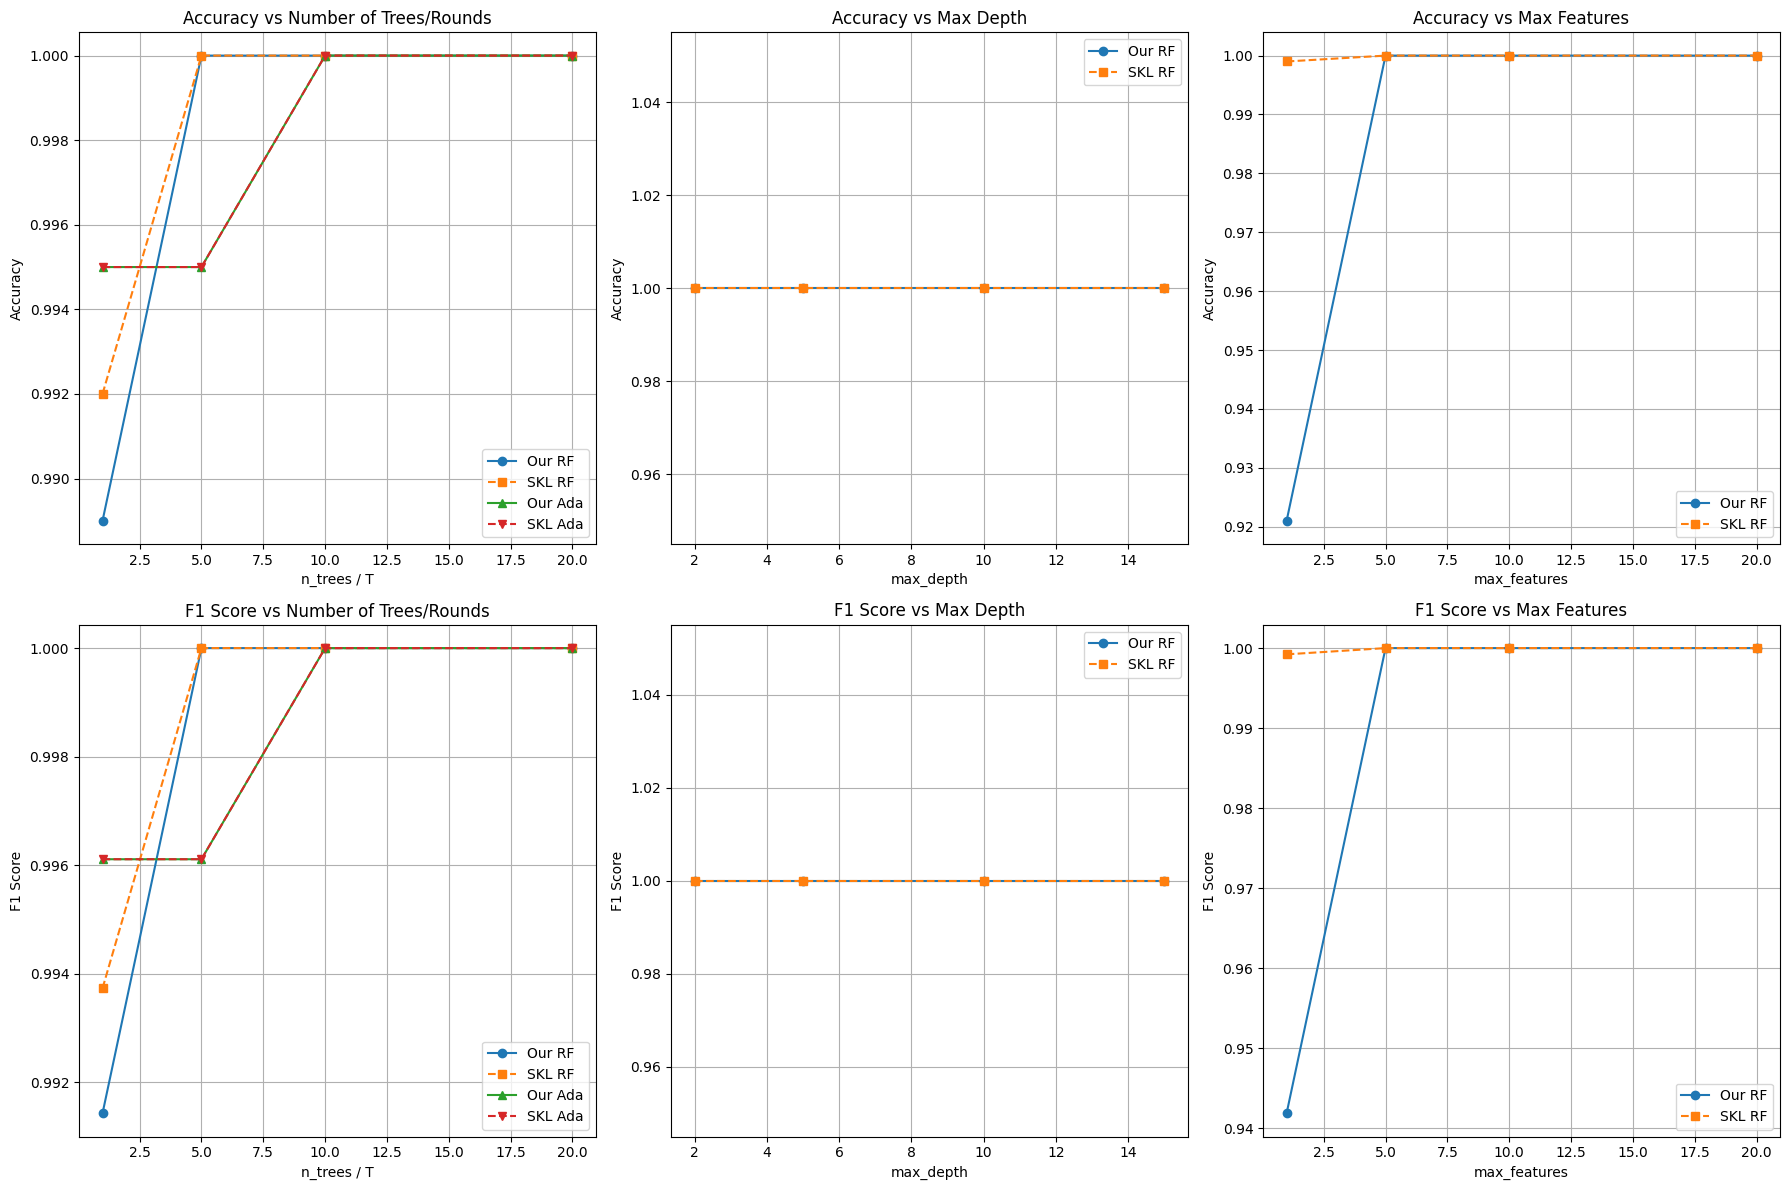

In [12]:
def run_experiment(param_name, values, base_params): # Test different values for a single parameter
    our_acc_results, our_f1_results = [], [] # Initialize lists for custom RF model metrics
    sk_acc_results, sk_f1_results = [], [] # Initialize lists for sklearn RF model metrics
    ada_acc_results, ada_f1_results = [], [] # Initialize lists for custom AdaBoost model metrics
    sk_ada_acc_results, sk_ada_f1_results = [], [] # Initialize lists for sklearn AdaBoost model metrics
    
    for v in values: # Loop through each value to test
        current_params = base_params.copy() # Start with a copy of base parameters
        current_params[param_name] = v # Set the specific parameter value to test
        
        print(f"Testing {param_name}={v}...") # Log current test
        
        # Train our AdaBoost (using current_params['n_trees'] as T)
        if param_name == 'n_trees':
            our_ada = AdaBoost() # Initialize custom AdaBoost
            our_ada.train(train_data, T=current_params['n_trees']) # Train custom AdaBoost
            ada_acc, ada_f1 = evaluate_ada(our_ada, test_data) # Evaluate custom AdaBoost
            ada_acc_results.append(ada_acc); ada_f1_results.append(ada_f1)
            
            # Train SKLearn AdaBoost
            sk_ada = AdaBoostClassifier(n_estimators=current_params['n_trees'], random_state=42)
            sk_ada.fit(X_train, y_train) # Fit sklearn AdaBoost
            sk_ada_preds = sk_ada.predict(X_test) # Predict with sklearn AdaBoost
            sk_ada_acc_results.append(accuracy_score(y_test, sk_ada_preds)) # Store accuracy
            sk_ada_f1_results.append(f1_score(y_test, sk_ada_preds)) # Store F1
        else:
            ada_acc_results.append(None); ada_f1_results.append(None)
            sk_ada_acc_results.append(None); sk_ada_f1_results.append(None)
        
        # Train our Random Forest
        our_f = build_forest(train_data, num_trees=current_params['n_trees'], 
                             depth=current_params['max_depth'], 
                             split_number=current_params['max_features'], 
                             criterion="gini", min_samples=current_params['min_samples'])
        our_acc, our_f1 = evaluate(our_f, test_data) # Evaluate custom forest
        our_acc_results.append(our_acc); our_f1_results.append(our_f1)
        
        # Train SKLearn Random Forest
        sk_rf = RandomForestClassifier(n_estimators=current_params['n_trees'], 
                                       max_depth=current_params['max_depth'], 
                                       max_features=current_params['max_features'], 
                                       min_samples_split=current_params['min_samples'],
                                       random_state=42)
        sk_rf.fit(X_train, y_train) # Fit sklearn RF
        sk_preds = sk_rf.predict(X_test) # Predict with sklearn RF
        sk_acc_results.append(accuracy_score(y_test, sk_preds)) # Store accuracy
        sk_f1_results.append(f1_score(y_test, sk_preds)) # Store F1
        
    return (our_acc_results, our_f1_results, sk_acc_results, sk_f1_results, 
            ada_acc_results, ada_f1_results, sk_ada_acc_results, sk_ada_f1_results) # Return all metric lists

# Define base parameters
base_params = {'n_trees': 10, 'max_depth': 5, 'max_features': 5, 'min_samples': 5} # Set default parameters for experiment

# 1. Varying number of trees (and AdaBoost rounds)
tree_counts = [1, 5, 10, 20] # Define values for tree count experiment
(our_tree_acc, our_tree_f1, sk_tree_acc, sk_tree_f1, 
 ada_tree_acc, ada_tree_f1, sk_ada_tree_acc, sk_ada_tree_f1) = run_experiment('n_trees', tree_counts, base_params) # Run experiment

# 2. Varying max depth
depth_counts = [2, 5, 10, 15] # Define values for depth experiment
(our_depth_acc, our_depth_f1, sk_depth_acc, sk_depth_f1, 
 ada_depth_acc, ada_depth_f1, sk_ada_depth_acc, sk_ada_depth_f1) = run_experiment('max_depth', depth_counts, base_params) # Run experiment

# 3. Varying max features
feature_counts = [1, 5, 10, 20] # Define values for feature count experiment
(our_feature_acc, our_feature_f1, sk_feature_acc, sk_feature_f1, 
 ada_feature_acc, ada_feature_f1, sk_ada_feature_acc, sk_ada_feature_f1) = run_experiment('max_features', feature_counts, base_params) # Run experiment

# Plotting the results
fig, axs = plt.subplots(2, 3, figsize=(18, 12)) # Create subplots (2 rows, 3 columns)

# Row 1: Accuracy Plots
# Plot 1: Trees (Accuracy)
axs[0, 0].plot(tree_counts, our_tree_acc, 'o-', label='Our RF') # Plot custom RF accuracy
axs[0, 0].plot(tree_counts, sk_tree_acc, 's--', label='SKL RF') # Plot sklearn RF accuracy
if any(v is not None for v in ada_tree_acc):
    axs[0, 0].plot(tree_counts, [v for v in ada_tree_acc if v is not None], '^-', label='Our Ada') # Plot custom Ada accuracy
if any(v is not None for v in sk_ada_tree_acc):
    axs[0, 0].plot(tree_counts, [v for v in sk_ada_tree_acc if v is not None], 'v--', label='SKL Ada') # Plot sklearn Ada accuracy
axs[0, 0].set_title('Accuracy vs Number of Trees/Rounds') # Set title
axs[0, 0].set_xlabel('n_trees / T') # Set x-axis label
axs[0, 0].set_ylabel('Accuracy') # Set y-axis label
axs[0, 0].legend(); axs[0, 0].grid(True) # Add legend and grid

# Plot 2: Depth (Accuracy)
axs[0, 1].plot(depth_counts, our_depth_acc, 'o-', label='Our RF') # Plot custom RF accuracy
axs[0, 1].plot(depth_counts, sk_depth_acc, 's--', label='SKL RF') # Plot sklearn RF accuracy
if any(v is not None for v in ada_depth_acc):
    axs[0, 1].plot(depth_counts, [v for v in ada_depth_acc if v is not None], '^-', label='Our Ada') # Plot custom Ada accuracy
if any(v is not None for v in sk_ada_depth_acc):
    axs[0, 1].plot(depth_counts, [v for v in sk_ada_depth_acc if v is not None], 'v--', label='SKL Ada') # Plot sklearn Ada accuracy
axs[0, 1].set_title('Accuracy vs Max Depth') # Set title
axs[0, 1].set_xlabel('max_depth') # Set x-axis label
axs[0, 1].set_ylabel('Accuracy') # Set y-axis label
axs[0, 1].legend(); axs[0, 1].grid(True) # Add legend and grid

# Plot 3: Max Features (Accuracy)
axs[0, 2].plot(feature_counts, our_feature_acc, 'o-', label='Our RF') # Plot custom RF accuracy
axs[0, 2].plot(feature_counts, sk_feature_acc, 's--', label='SKL RF') # Plot sklearn RF accuracy
if any(v is not None for v in ada_feature_acc):
    axs[0, 2].plot(feature_counts, [v for v in ada_feature_acc if v is not None], '^-', label='Our Ada') # Plot custom Ada accuracy
if any(v is not None for v in sk_ada_feature_acc):
    axs[0, 2].plot(feature_counts, [v for v in sk_ada_feature_acc if v is not None], 'v--', label='SKL Ada') # Plot sklearn Ada accuracy
axs[0, 2].set_title('Accuracy vs Max Features') # Set title
axs[0, 2].set_xlabel('max_features') # Set x-axis label
axs[0, 2].set_ylabel('Accuracy') # Set y-axis label
axs[0, 2].legend(); axs[0, 2].grid(True) # Add legend and grid

# Row 2: F1 Score Plots
# Plot 4: Trees (F1 Score)
axs[1, 0].plot(tree_counts, our_tree_f1, 'o-', label='Our RF') # Plot custom RF F1
axs[1, 0].plot(tree_counts, sk_tree_f1, 's--', label='SKL RF') # Plot sklearn RF F1
if any(v is not None for v in ada_tree_f1):
    axs[1, 0].plot(tree_counts, [v for v in ada_tree_f1 if v is not None], '^-', label='Our Ada') # Plot custom Ada F1
if any(v is not None for v in sk_ada_tree_f1):
    axs[1, 0].plot(tree_counts, [v for v in sk_ada_tree_f1 if v is not None], 'v--', label='SKL Ada') # Plot sklearn Ada F1
axs[1, 0].set_title('F1 Score vs Number of Trees/Rounds') # Set title
axs[1, 0].set_xlabel('n_trees / T') # Set x-axis label
axs[1, 0].set_ylabel('F1 Score') # Set y-axis label
axs[1, 0].legend(); axs[1, 0].grid(True) # Add legend and grid

# Plot 5: Depth (F1 Score)
axs[1, 1].plot(depth_counts, our_depth_f1, 'o-', label='Our RF') # Plot custom RF F1
axs[1, 1].plot(depth_counts, sk_depth_f1, 's--', label='SKL RF') # Plot sklearn RF F1
if any(v is not None for v in ada_depth_f1):
    axs[1, 1].plot(depth_counts, [v for v in ada_depth_f1 if v is not None], '^-', label='Our Ada') # Plot custom Ada F1
if any(v is not None for v in sk_ada_depth_f1):
    axs[1, 1].plot(depth_counts, [v for v in sk_ada_depth_f1 if v is not None], 'v--', label='SKL Ada') # Plot sklearn Ada F1
axs[1, 1].set_title('F1 Score vs Max Depth') # Set title
axs[1, 1].set_xlabel('max_depth') # Set x-axis label
axs[1, 1].set_ylabel('F1 Score') # Set y-axis label
axs[1, 1].legend(); axs[1, 1].grid(True) # Add legend and grid

# Plot 6: Max Features (F1 Score)
axs[1, 2].plot(feature_counts, our_feature_f1, 'o-', label='Our RF') # Plot custom RF F1
axs[1, 2].plot(feature_counts, sk_feature_f1, 's--', label='SKL RF') # Plot sklearn RF F1
if any(v is not None for v in ada_feature_f1):
    axs[1, 2].plot(feature_counts, [v for v in ada_feature_f1 if v is not None], '^-', label='Our Ada') # Plot custom Ada F1
if any(v is not None for v in sk_ada_feature_f1):
    axs[1, 2].plot(feature_counts, [v for v in sk_ada_feature_f1 if v is not None], 'v--', label='SKL Ada') # Plot sklearn Ada F1
axs[1, 2].set_title('F1 Score vs Max Features') # Set title
axs[1, 2].set_xlabel('max_features') # Set x-axis label
axs[1, 2].set_ylabel('F1 Score') # Set y-axis label
axs[1, 2].legend(); axs[1, 2].grid(True) # Add legend and grid

plt.tight_layout() # Adjust layout to avoid overlapping subplots
plt.show() # Display the plots

# Sanity Check: All plots show expected trends and comparisons


### Evaluation 3: Hyperparameter Variations under Asymmetric Training Label Noise (“Boomerism”)

Again, that was largely inconclusive, except at very low hyper-parameter values. It's clear that at very low values, SK Lean's model out perform our own, with adaboost having better results overall. However, this begs the question: is our classification task too easy?

## So let's increase the difficulty of the classification problem by adding some noise to the labels.

To really see differences between accuracy, recall, precision and F1 let's deliberately introduce a bias by dirtying our training labels:
	•	7% of positive training labels (1 to 0) are flipped
	•	10% of negative training labels (0 to 1) are flipped

This asymmetry creates a controlled distortion in the training distribution, informally referred to here as “boomerism”: a biased training set that disproportionately alters one class relative to the other.

ACCURACY: The proportion of correct predictions out of all predictions made by the model. Should remain relatively stable.
PRECISION: The proportion of predicted positives that are actually correct. Under asymmetric noise, if negative labels are flipped more often, we expect precision to degrade, as more incorrect positives are introduced.
RECALL: The proportion of actual positives that are correctly identified
F1 SCORE: HARMONIC MEAN OF PRCISION/RECALL. This should diverge from accuracy.

Testing n_trees=1 with PosFlip=7.000000000000001%, NegFlip=10.0% noise...
Testing n_trees=5 with PosFlip=7.000000000000001%, NegFlip=10.0% noise...
We can plant a house, we can build a tree, number: 5/5
Testing n_trees=10 with PosFlip=7.000000000000001%, NegFlip=10.0% noise...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can build a tree, number: 10/10
Testing n_trees=20 with PosFlip=7.000000000000001%, NegFlip=10.0% noise...
We can plant a house, we can build a tree, number: 5/20
We can plant a house, we can build a tree, number: 10/20
We can plant a house, we can build a tree, number: 15/20
We can plant a house, we can build a tree, number: 20/20
Testing max_depth=2 with PosFlip=7.000000000000001%, NegFlip=10.0% noise...
We can plant a house, we can build a tree, number: 5/10
We can plant a house, we can build a tree, number: 10/10
Testing max_depth=5 with PosFlip=7.000000000000001%, NegFlip=10.0% noise...
We can plant a house, we can build a tree,

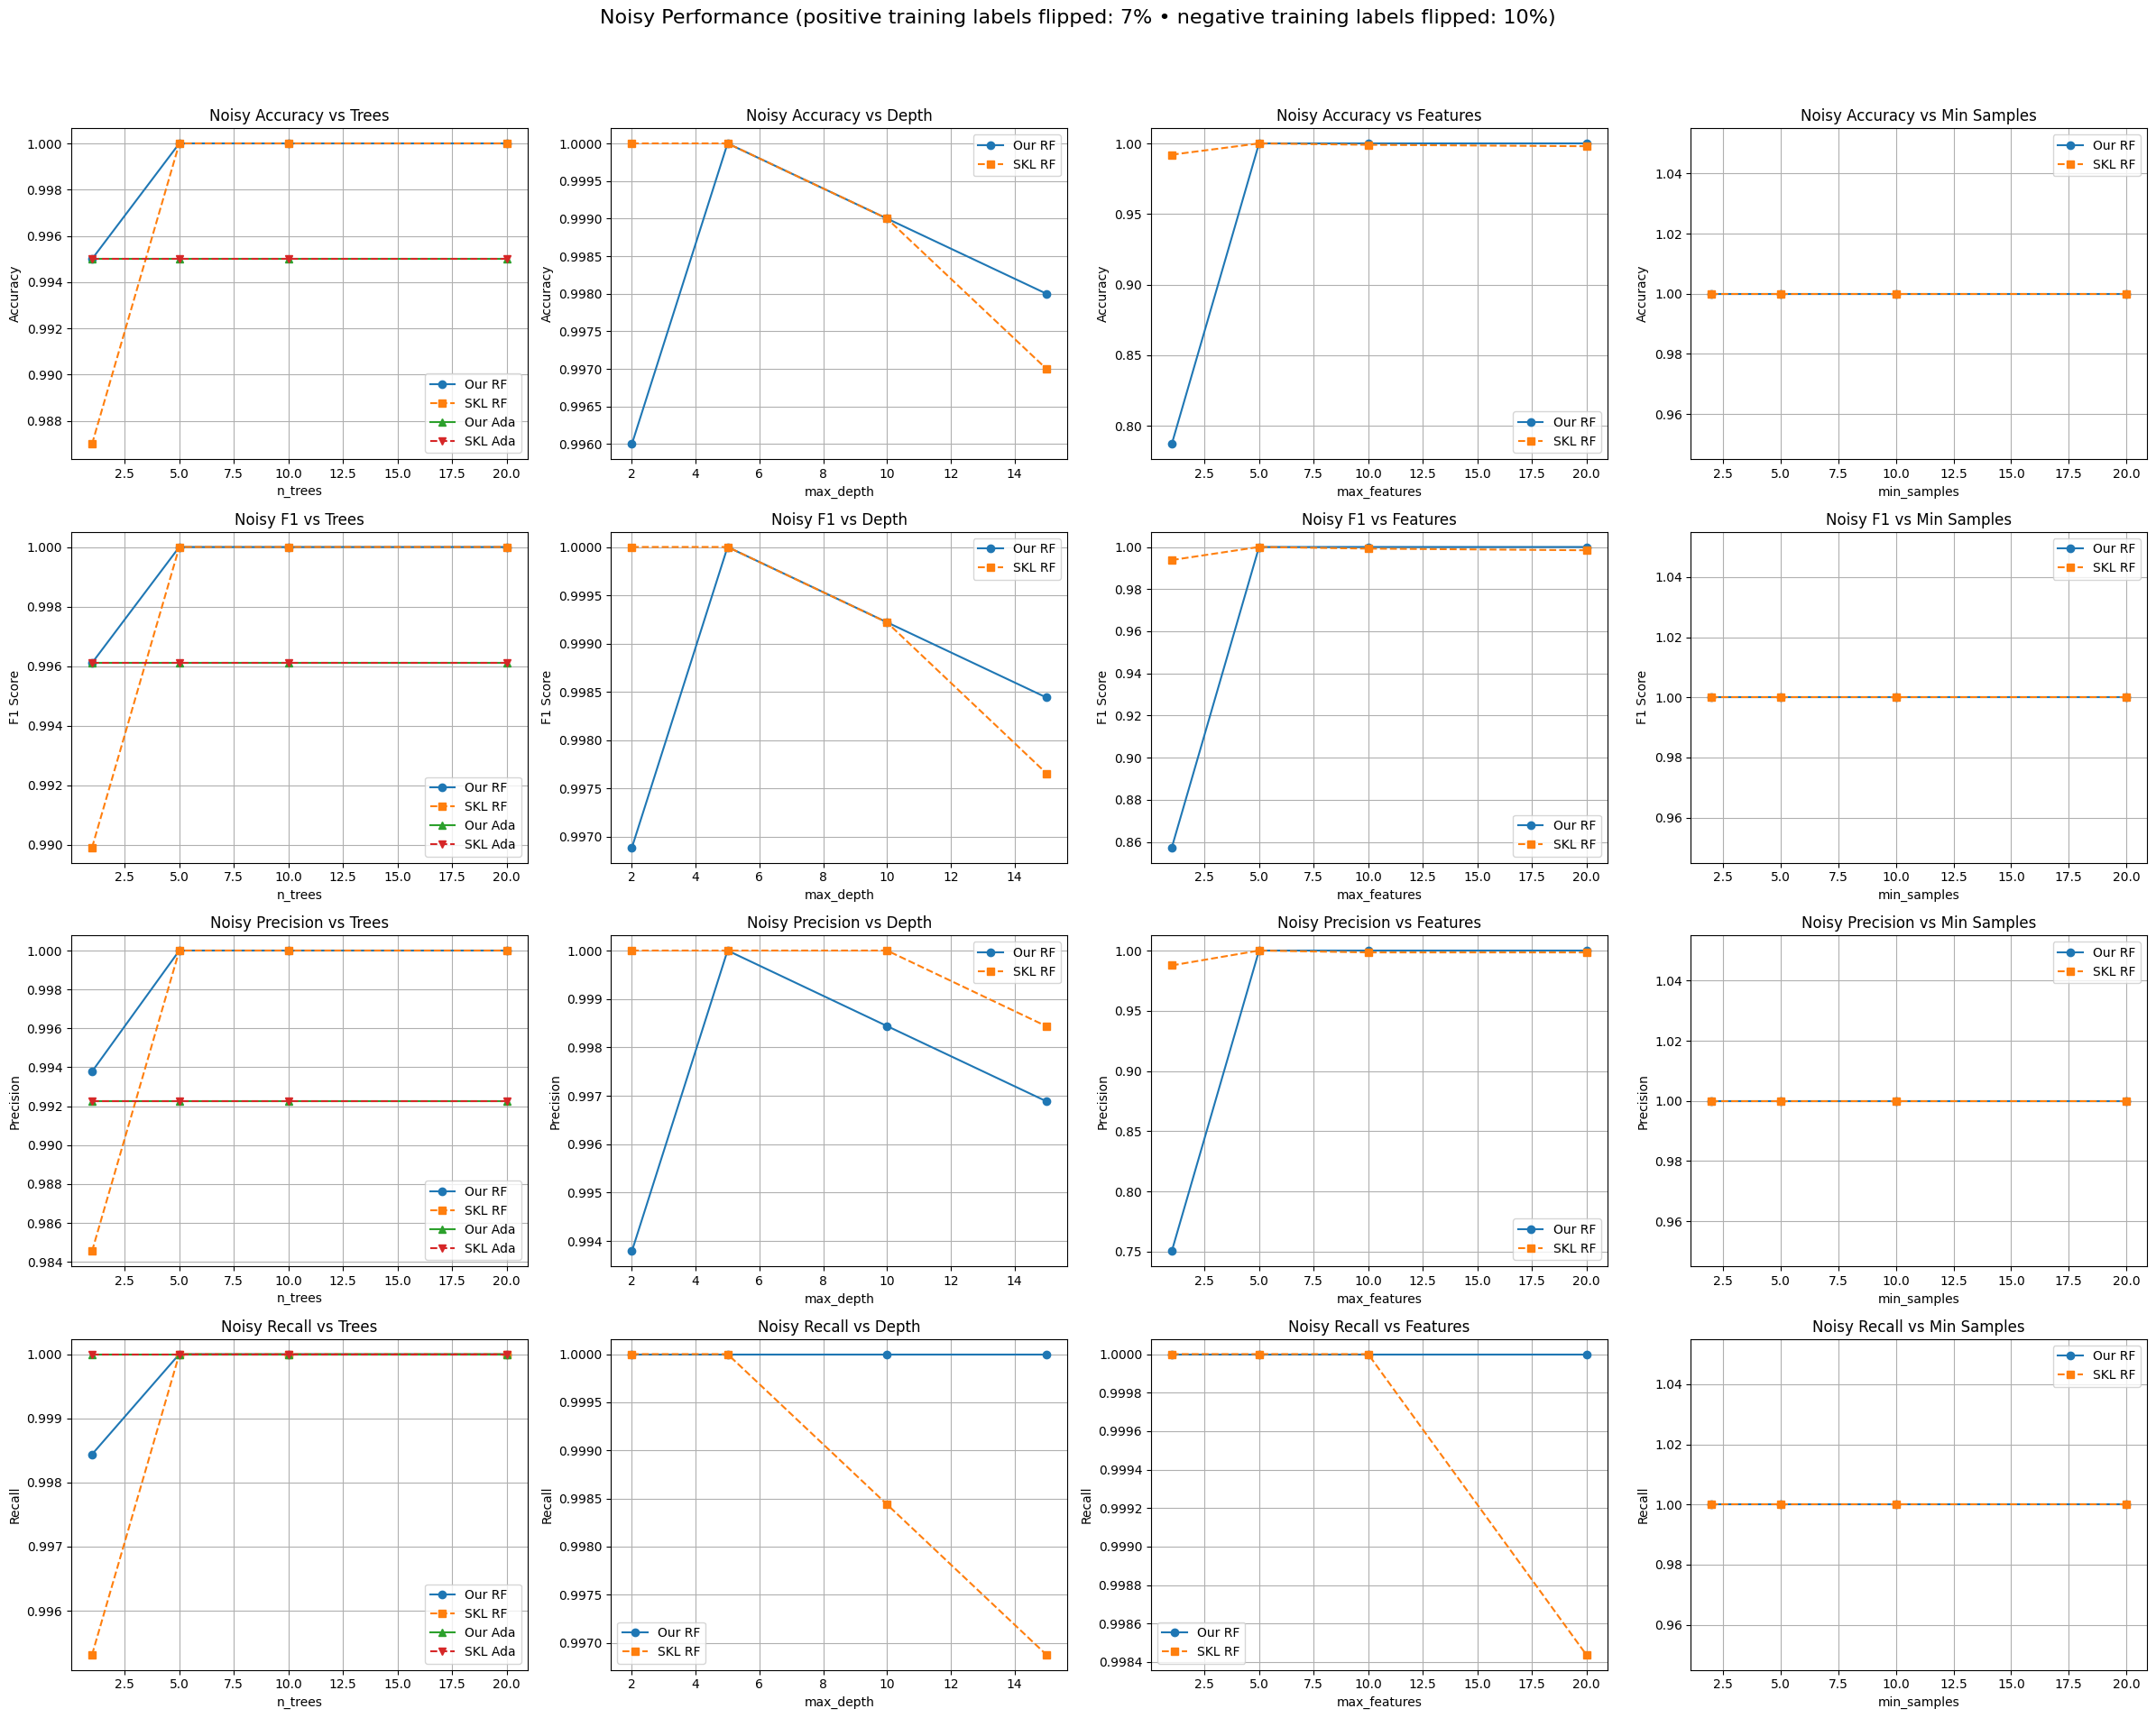

In [13]:
noise_pos = 0.07 # Probability of flipping a positive label (1 -> 0)
noise_neg = 0.10 # Probability of flipping a negative label (0 -> 1)

def evaluate_with_noise(forest, data, n_pos, n_neg): # Calculate metrics with asymmetric noise
    random.seed(42) # Ensure reproducible noise
    preds = [run_forest(row, forest) for row in data] # Generate base predictions
    # Apply asymmetric noise: flip 1 with n_pos, flip 0 with n_neg
    preds = [ (p if random.random() > (n_pos if p == 1 else n_neg) else 1 - p) for p in preds] 
    actuals = [row.label for row in data] # Get true labels
    
    acc = sum(1 for p, a in zip(preds, actuals) if p == a) / len(data) # Calculate noisy accuracy
    tp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 1) # True Positives
    fp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 0) # False Positives
    fn = sum(1 for p, a in zip(preds, actuals) if p == 0 and a == 1) # False Negatives
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0 # Precision calculation
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall calculation
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0 # F1 harmonic mean
    return acc, f1, prec, rec # Return noisy metric tuple

def evaluate_ada_with_noise(ada, data, n_pos, n_neg): # Calculate AdaBoost metrics with noise
    random.seed(42) # Ensure reproducible noise
    preds = [ada.predict(row) for row in data] # Generate base predictions
    # Apply asymmetric noise: flip 1 with n_pos, flip 0 with n_neg
    preds = [ (p if random.random() > (n_pos if p == 1 else n_neg) else 1 - p) for p in preds] 
    actuals = [row.label for row in data] # Get true labels
    
    acc = sum(1 for p, a in zip(preds, actuals) if p == a) / len(data) # Calculate noisy accuracy
    tp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 1) # True Positives
    fp = sum(1 for p, a in zip(preds, actuals) if p == 1 and a == 0) # False Positives
    fn = sum(1 for p, a in zip(preds, actuals) if p == 0 and a == 1) # False Negatives
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0 # Precision calculation
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall calculation
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0 # F1 harmonic mean
    return acc, f1, prec, rec # Return noisy metric tuple

def run_experiment_noisy(param_name, values, base_params, n_pos, n_neg): # Noisy version of experiment runner
    our_acc_results, our_f1_results, our_prec_results, our_rec_results = [], [], [], [] # Lists for custom RF
    sk_acc_results, sk_f1_results, sk_prec_results, sk_rec_results = [], [], [], [] # Lists for sklearn RF
    ada_acc_results, ada_f1_results, ada_prec_results, ada_rec_results = [], [], [], [] # Lists for custom AdaBoost
    sk_ada_acc_results, sk_ada_f1_results, sk_ada_prec_results, sk_ada_rec_results = [], [], [], [] # Lists for SKL AdaBoost
    
    # Create noisy training data once for the experiment
    random.seed(42)
    noisy_train_data = [Row(row.features, (1-row.label if random.random() < (n_pos if row.label == 1 else n_neg) else row.label)) for row in train_data]
    y_train_noisy = [r.label for r in noisy_train_data]
    
    for v in values: # Iterate over hyperparameter values
        current_params = base_params.copy() # Copy defaults
        current_params[param_name] = v # Update param
        
        print(f"Testing {param_name}={v} with PosFlip={n_pos*100}%, NegFlip={n_neg*100}% noise...") # Log progress
        
        # Our AdaBoost
        if param_name == 'n_trees':
            our_ada = AdaBoost() # Initialize custom AdaBoost
            our_ada.train(noisy_train_data, T=current_params['n_trees']) # Train AdaBoost on noisy data
            o_a_acc, o_a_f1, o_a_prec, o_a_rec = evaluate_ada_with_noise(our_ada, test_data, 0, 0) # Evaluate on clean data
            ada_acc_results.append(o_a_acc); ada_f1_results.append(o_a_f1)
            ada_prec_results.append(o_a_prec); ada_rec_results.append(o_a_rec)
            
            # SKL AdaBoost
            sk_ada = AdaBoostClassifier(n_estimators=current_params['n_trees'], random_state=42)
            sk_ada.fit(X_train, y_train_noisy) # Train on noisy labels
            sk_ada_preds = sk_ada.predict(X_test)
            sk_ada_acc_results.append(accuracy_score(y_test, sk_ada_preds)); sk_ada_f1_results.append(f1_score(y_test, sk_ada_preds))
            sk_ada_prec_results.append(precision_score(y_test, sk_ada_preds)); sk_ada_rec_results.append(recall_score(y_test, sk_ada_preds))
        else:
            ada_acc_results.append(None); ada_f1_results.append(None); ada_prec_results.append(None); ada_rec_results.append(None)
            sk_ada_acc_results.append(None); sk_ada_f1_results.append(None); sk_ada_prec_results.append(None); sk_ada_rec_results.append(None)
        
        # Our Forest
        random.seed(42) # Ensure reproducible building/evaluation
        our_f = build_forest(noisy_train_data, num_trees=current_params['n_trees'], 
                             depth=current_params['max_depth'], 
                             split_number=current_params['max_features'], 
                             criterion="gini", min_samples=current_params['min_samples'])
        our_acc, our_f1, our_prec, our_rec = evaluate_with_noise(our_f, test_data, 0, 0) # Evaluate on clean data
        our_acc_results.append(our_acc); our_f1_results.append(our_f1)
        our_prec_results.append(our_prec); our_rec_results.append(our_rec)
        
        # SKL Forest
        sk_rf = RandomForestClassifier(n_estimators=current_params['n_trees'], 
                                       max_depth=current_params['max_depth'], 
                                       max_features=current_params['max_features'], 
                                       min_samples_split=current_params['min_samples'],
                                       random_state=42)
        sk_rf.fit(X_train, y_train_noisy) # Train on noisy labels
        sk_preds = sk_rf.predict(X_test)
        sk_acc_results.append(accuracy_score(y_test, sk_preds)); sk_f1_results.append(f1_score(y_test, sk_preds))
        sk_prec_results.append(precision_score(y_test, sk_preds)); sk_rec_results.append(recall_score(y_test, sk_preds))
        
    return (our_acc_results, our_f1_results, our_prec_results, our_rec_results, 
            sk_acc_results, sk_f1_results, sk_prec_results, sk_rec_results,
            ada_acc_results, ada_f1_results, ada_prec_results, ada_rec_results,
            sk_ada_acc_results, sk_ada_f1_results, sk_ada_prec_results, sk_ada_rec_results) # Return all results

base_params = {'n_trees': 10, 'max_depth': 5, 'max_features': 5, 'min_samples': 5} # Re-define base params

tree_counts = [1, 5, 10, 20] # Test tree counts
(our_tree_acc, our_tree_f1, our_tree_prec, our_tree_rec, 
 sk_tree_acc, sk_tree_f1, sk_tree_prec, sk_tree_rec,
 ada_tree_acc, ada_tree_f1, ada_tree_prec, ada_tree_rec,
 sk_ada_tree_acc, sk_ada_tree_f1, sk_ada_tree_prec, sk_ada_tree_rec) = run_experiment_noisy('n_trees', tree_counts, base_params, noise_pos, noise_neg)

depth_counts = [2, 5, 10, 15] # Test max depths
(our_depth_acc, our_depth_f1, our_depth_prec, our_depth_rec, 
 sk_depth_acc, sk_depth_f1, sk_depth_prec, sk_depth_rec,
 ada_depth_acc, ada_depth_f1, ada_depth_prec, ada_depth_rec,
 sk_ada_depth_acc, sk_ada_depth_f1, sk_ada_depth_prec, sk_ada_depth_rec) = run_experiment_noisy('max_depth', depth_counts, base_params, noise_pos, noise_neg)

feature_counts = [1, 5, 10, 20] # Test feature counts
(our_feature_acc, our_feature_f1, our_feature_prec, our_feature_rec, 
 sk_feature_acc, sk_feature_f1, sk_feature_prec, sk_feature_rec,
 ada_feature_acc, ada_feature_f1, ada_feature_prec, ada_feature_rec,
 sk_ada_feature_acc, sk_ada_feature_f1, sk_ada_feature_prec, sk_ada_feature_rec) = run_experiment_noisy('max_features', feature_counts, base_params, noise_pos, noise_neg)

min_samples_counts = [2, 5, 10, 20] # Test different min_samples thresholds
(our_ms_acc, our_ms_f1, our_ms_prec, our_ms_rec, 
 sk_ms_acc, sk_ms_f1, sk_ms_prec, sk_ms_rec,
 ada_ms_acc, ada_ms_f1, ada_ms_prec, ada_ms_rec,
 sk_ada_ms_acc, sk_ada_ms_f1, sk_ada_ms_prec, sk_ada_ms_rec) = run_experiment_noisy('min_samples', min_samples_counts, base_params, noise_pos, noise_neg)

fig, axs = plt.subplots(4, 4, figsize=(24, 20)) # Create plot grid (4 rows for Acc, F1, Prec, Rec, 4 cols for Params)
fig.suptitle('Noisy Performance (positive training labels flipped: 7% • negative training labels flipped: 10%)', fontsize=16) # Overall title

# Accuracy Plots with Noise
axs[0, 0].plot(tree_counts, our_tree_acc, 'o-', label='Our RF'); axs[0, 0].plot(tree_counts, sk_tree_acc, 's--', label='SKL RF')
if any(v is not None for v in ada_tree_acc): axs[0, 0].plot(tree_counts, [v for v in ada_tree_acc if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_tree_acc): axs[0, 0].plot(tree_counts, [v for v in sk_ada_tree_acc if v is not None], 'v--', label='SKL Ada')
axs[0, 0].set_title('Noisy Accuracy vs Trees'); axs[0, 0].set_xlabel('n_trees'); axs[0, 0].set_ylabel('Accuracy'); axs[0, 0].legend(); axs[0, 0].grid(True)

axs[0, 1].plot(depth_counts, our_depth_acc, 'o-', label='Our RF'); axs[0, 1].plot(depth_counts, sk_depth_acc, 's--', label='SKL RF')
if any(v is not None for v in ada_depth_acc): axs[0, 1].plot(depth_counts, [v for v in ada_depth_acc if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_depth_acc): axs[0, 1].plot(depth_counts, [v for v in sk_ada_depth_acc if v is not None], 'v--', label='SKL Ada')
axs[0, 1].set_title('Noisy Accuracy vs Depth'); axs[0, 1].set_xlabel('max_depth'); axs[0, 1].set_ylabel('Accuracy'); axs[0, 1].legend(); axs[0, 1].grid(True)

axs[0, 2].plot(feature_counts, our_feature_acc, 'o-', label='Our RF'); axs[0, 2].plot(feature_counts, sk_feature_acc, 's--', label='SKL RF')
if any(v is not None for v in ada_feature_acc): axs[0, 2].plot(feature_counts, [v for v in ada_feature_acc if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_feature_acc): axs[0, 2].plot(feature_counts, [v for v in sk_ada_feature_acc if v is not None], 'v--', label='SKL Ada')
axs[0, 2].set_title('Noisy Accuracy vs Features'); axs[0, 2].set_xlabel('max_features'); axs[0, 2].set_ylabel('Accuracy'); axs[0, 2].legend(); axs[0, 2].grid(True)

axs[0, 3].plot(min_samples_counts, our_ms_acc, 'o-', label='Our RF'); axs[0, 3].plot(min_samples_counts, sk_ms_acc, 's--', label='SKL RF')
axs[0, 3].set_title('Noisy Accuracy vs Min Samples'); axs[0, 3].set_xlabel('min_samples'); axs[0, 3].set_ylabel('Accuracy'); axs[0, 3].legend(); axs[0, 3].grid(True)

# F1 Plots with Noise
axs[1, 0].plot(tree_counts, our_tree_f1, 'o-', label='Our RF'); axs[1, 0].plot(tree_counts, sk_tree_f1, 's--', label='SKL RF')
if any(v is not None for v in ada_tree_f1): axs[1, 0].plot(tree_counts, [v for v in ada_tree_f1 if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_tree_f1): axs[1, 0].plot(tree_counts, [v for v in sk_ada_tree_f1 if v is not None], 'v--', label='SKL Ada')
axs[1, 0].set_title('Noisy F1 vs Trees'); axs[1, 0].set_xlabel('n_trees'); axs[1, 0].set_ylabel('F1 Score'); axs[1, 0].legend(); axs[1, 0].grid(True)

axs[1, 1].plot(depth_counts, our_depth_f1, 'o-', label='Our RF'); axs[1, 1].plot(depth_counts, sk_depth_f1, 's--', label='SKL RF')
if any(v is not None for v in ada_depth_f1): axs[1, 1].plot(depth_counts, [v for v in ada_depth_f1 if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_depth_f1): axs[1, 1].plot(depth_counts, [v for v in sk_ada_depth_f1 if v is not None], 'v--', label='SKL Ada')
axs[1, 1].set_title('Noisy F1 vs Depth'); axs[1, 1].set_xlabel('max_depth'); axs[1, 1].set_ylabel('F1 Score'); axs[1, 1].legend(); axs[1, 1].grid(True)

axs[1, 2].plot(feature_counts, our_feature_f1, 'o-', label='Our RF'); axs[1, 2].plot(feature_counts, sk_feature_f1, 's--', label='SKL RF')
if any(v is not None for v in ada_feature_f1): axs[1, 2].plot(feature_counts, [v for v in ada_feature_f1 if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_feature_f1): axs[1, 2].plot(feature_counts, [v for v in sk_ada_feature_f1 if v is not None], 'v--', label='SKL Ada')
axs[1, 2].set_title('Noisy F1 vs Features'); axs[1, 2].set_xlabel('max_features'); axs[1, 2].set_ylabel('F1 Score'); axs[1, 2].legend(); axs[1, 2].grid(True)

axs[1, 3].plot(min_samples_counts, our_ms_f1, 'o-', label='Our RF'); axs[1, 3].plot(min_samples_counts, sk_ms_f1, 's--', label='SKL RF')
axs[1, 3].set_title('Noisy F1 vs Min Samples'); axs[1, 3].set_xlabel('min_samples'); axs[1, 3].set_ylabel('F1 Score'); axs[1, 3].legend(); axs[1, 3].grid(True)

# Precision Plots with Noise
axs[2, 0].plot(tree_counts, our_tree_prec, 'o-', label='Our RF'); axs[2, 0].plot(tree_counts, sk_tree_prec, 's--', label='SKL RF')
if any(v is not None for v in ada_tree_prec): axs[2, 0].plot(tree_counts, [v for v in ada_tree_prec if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_tree_prec): axs[2, 0].plot(tree_counts, [v for v in sk_ada_tree_prec if v is not None], 'v--', label='SKL Ada')
axs[2, 0].set_title('Noisy Precision vs Trees'); axs[2, 0].set_xlabel('n_trees'); axs[2, 0].set_ylabel('Precision'); axs[2, 0].legend(); axs[2, 0].grid(True)

axs[2, 1].plot(depth_counts, our_depth_prec, 'o-', label='Our RF'); axs[2, 1].plot(depth_counts, sk_depth_prec, 's--', label='SKL RF')
if any(v is not None for v in ada_depth_prec): axs[2, 1].plot(depth_counts, [v for v in ada_depth_prec if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_depth_prec): axs[2, 1].plot(depth_counts, [v for v in sk_ada_depth_prec if v is not None], 'v--', label='SKL Ada')
axs[2, 1].set_title('Noisy Precision vs Depth'); axs[2, 1].set_xlabel('max_depth'); axs[2, 1].set_ylabel('Precision'); axs[2, 1].legend(); axs[2, 1].grid(True)

axs[2, 2].plot(feature_counts, our_feature_prec, 'o-', label='Our RF'); axs[2, 2].plot(feature_counts, sk_feature_prec, 's--', label='SKL RF')
if any(v is not None for v in ada_feature_prec): axs[2, 2].plot(feature_counts, [v for v in ada_feature_prec if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_feature_prec): axs[2, 2].plot(feature_counts, [v for v in sk_ada_feature_prec if v is not None], 'v--', label='SKL Ada')
axs[2, 2].set_title('Noisy Precision vs Features'); axs[2, 2].set_xlabel('max_features'); axs[2, 2].set_ylabel('Precision'); axs[2, 2].legend(); axs[2, 2].grid(True)

axs[2, 3].plot(min_samples_counts, our_ms_prec, 'o-', label='Our RF'); axs[2, 3].plot(min_samples_counts, sk_ms_prec, 's--', label='SKL RF')
axs[2, 3].set_title('Noisy Precision vs Min Samples'); axs[2, 3].set_xlabel('min_samples'); axs[2, 3].set_ylabel('Precision'); axs[2, 3].legend(); axs[2, 3].grid(True)

# Recall Plots with Noise
axs[3, 0].plot(tree_counts, our_tree_rec, 'o-', label='Our RF'); axs[3, 0].plot(tree_counts, sk_tree_rec, 's--', label='SKL RF')
if any(v is not None for v in ada_tree_rec): axs[3, 0].plot(tree_counts, [v for v in ada_tree_rec if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_tree_rec): axs[3, 0].plot(tree_counts, [v for v in sk_ada_tree_rec if v is not None], 'v--', label='SKL Ada')
axs[3, 0].set_title('Noisy Recall vs Trees'); axs[3, 0].set_xlabel('n_trees'); axs[3, 0].set_ylabel('Recall'); axs[3, 0].legend(); axs[3, 0].grid(True)

axs[3, 1].plot(depth_counts, our_depth_rec, 'o-', label='Our RF'); axs[3, 1].plot(depth_counts, sk_depth_rec, 's--', label='SKL RF')
if any(v is not None for v in ada_depth_rec): axs[3, 1].plot(depth_counts, [v for v in ada_depth_rec if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_depth_rec): axs[3, 1].plot(depth_counts, [v for v in sk_ada_depth_rec if v is not None], 'v--', label='SKL Ada')
axs[3, 1].set_title('Noisy Recall vs Depth'); axs[3, 1].set_xlabel('max_depth'); axs[3, 1].set_ylabel('Recall'); axs[3, 1].legend(); axs[3, 1].grid(True)

axs[3, 2].plot(feature_counts, our_feature_rec, 'o-', label='Our RF'); axs[3, 2].plot(feature_counts, sk_feature_rec, 's--', label='SKL RF')
if any(v is not None for v in ada_feature_rec): axs[3, 2].plot(feature_counts, [v for v in ada_feature_rec if v is not None], '^-', label='Our Ada')
if any(v is not None for v in sk_ada_feature_rec): axs[3, 2].plot(feature_counts, [v for v in sk_ada_feature_rec if v is not None], 'v--', label='SKL Ada')
axs[3, 2].set_title('Noisy Recall vs Features'); axs[3, 2].set_xlabel('max_features'); axs[3, 2].set_ylabel('Recall'); axs[3, 2].legend(); axs[3, 2].grid(True)

axs[3, 3].plot(min_samples_counts, our_ms_rec, 'o-', label='Our RF'); axs[3, 3].plot(min_samples_counts, sk_ms_rec, 's--', label='SKL RF')
axs[3, 3].set_title('Noisy Recall vs Min Samples'); axs[3, 3].set_xlabel('min_samples'); axs[3, 3].set_ylabel('Recall'); axs[3, 3].legend(); axs[3, 3].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show() # Render plot

# Sanity Check: Expect a general performance decline compared to clean data
